# Project - Car Detection in Snow Environment

In [ ]:
print("Starting Project")

Starting Project


## Imports

In [10]:
# basic imports
import os
import sys
import yaml

# Preprocessing
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from collections import defaultdict

# network imports
#import yolov9.train
#from ultralytics import YOLO as yolov9
#import torch #?


# logging imports
#import wandb

## Logging setup

In [ ]:
xs = []
ys_train = []
ys_valid = []

## Pre-processing data

Saved 8028 at the location frames/2022-12-04 Bjenberg 02


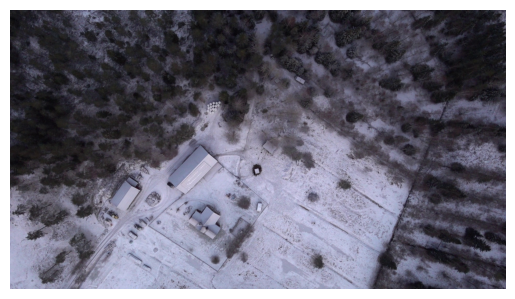

In [6]:
video_path = "Train/2022-12-04 Bjenberg 02/2022-12-04 Bjenberg 02.MP4"
output_dir = "frames/2022-12-04 Bjenberg 02"

os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path) # Choose which file

if not cap.isOpened(): # If it cannot see the video
    raise ValueError

framed_id = 0

while True:
    ret, frame = cap.read()
    if not ret: # ret is boolean for how it did go to read the frame from the video.
        break

    frame_path = os.path.join(output_dir, f"frame_{framed_id:06d}.jpg")
    cv2.imwrite(frame_path, frame)

    framed_id += 1
cap.release() # Closes the file, like file.close but for videos and cameras.

print(f"Saved {framed_id} at the location {output_dir}")

img = cv2.imread("frames/2022-12-04 Bjenberg 02/frame_000333.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

[{'track_id': 0, 'label': 'car', 'frame': 1, 'bbox': [25.31, 860.77, 57.72, 875.84]}, {'track_id': 0, 'label': 'car', 'frame': 2, 'bbox': [23.0, 865.0, 53.0, 877.0]}]
Antal frames med annotationer: 4030
Exempel frame 0: [{'track_id': 10, 'label': 'car', 'bbox': [7.04, 955.86, 34.8, 968.33]}, {'track_id': 55, 'label': 'car', 'bbox': [289.85, 887.52, 305.15, 925.56]}]


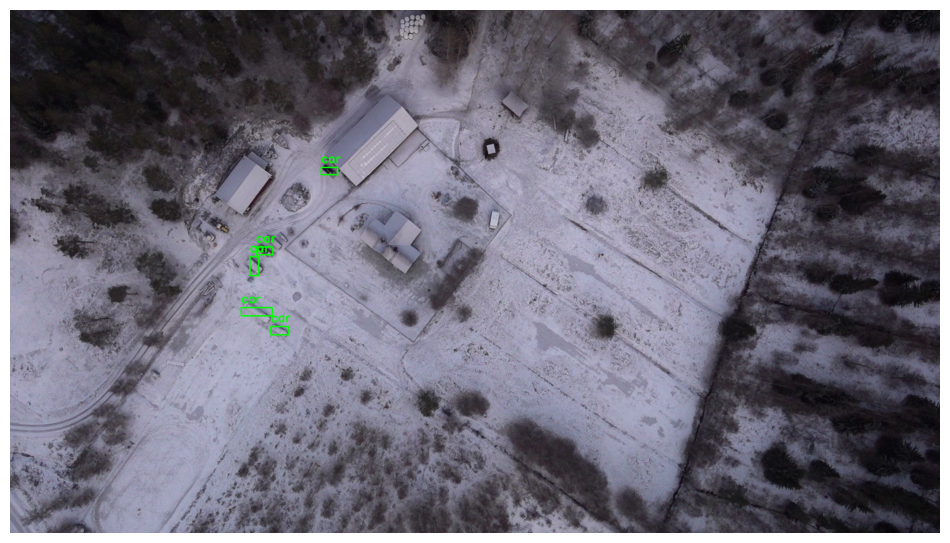

In [ ]:
# ----------------------------------- Add Boxes to the Frames -----------------------------------

xml_path = "Train/2022-12-04 Bjenberg 02/2022-12-04 Bjenberg 02.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

annotations = []

for track in root.findall("track"):
    track_id = int(track.attrib["id"])
    label = track.attrib["label"]

    for box in track.findall("box"):
        frame = int(box.attrib["frame"])
        xtl = float(box.attrib["xtl"])
        ytl = float(box.attrib["ytl"])
        xbr = float(box.attrib["xbr"])
        ybr = float(box.attrib["ybr"])

        annotations.append({
            "track_id": track_id,
            "label": label,
            "frame": frame,
            "bbox": [xtl, ytl, xbr, ybr]
        })

print(annotations[:2])

frame_annotations = defaultdict(list)

for ann in annotations:
    frame_annotations[ann["frame"]].append({
        "track_id": ann["track_id"],
        "label": ann["label"],
        "bbox": ann["bbox"]
    })

print("Antal frames med annotationer:", len(frame_annotations))
print("Exempel frame 0:", frame_annotations[0])

# ----------------------------------- Visualization if code = correct -----------------------------------

video_path = "Train/2022-12-04 Bjenberg 02/2022-12-04 Bjenberg 02.MP4"
target_frame = 200

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame) # Start from index values target_frame
ret, frame = cap.read()
cap.release() # We only read one file, therefore we close this very quickly


if not ret: 
    raise ValueError

for ann in frame_annotations[target_frame]: # all frames with annotations
    x1, y1, x2, y2 = map(int, ann["bbox"]) # Get box-coordinates
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText( # write Car over box
        frame,
        ann["label"],
        (x1, max(20, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0), # Green Colour
        2
    )

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## Setting up the network

In [ ]:
# YOLOv9

## Training and validation

### Default settings for run

In [ ]:
# Model and optimizer hyperparameters
model =
optimizer =

# Scheduler hyperparameters
sch_factor = 0.1
patience = 3

# Run hyperparameters
epochs = 100
ran_epochs = 0

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode="min",
        factor = sch_factor, 
        patience = patience # Wait x amount of epochs before reducing lr
    )

In [ ]:

for epoch in range(epochs):
    '''
    Train the model for one epoch, and log the training and validation metrics to Weights & Biases.

    ran_epochs: keeps track of how many epochs have been run
    
    '''
    ran_epochs.append(epoch)
    print(f"Epoch {epoch+1}/{epochs}")

    # ------------------------- TRAIN -------------------------
    train_running_loss = 0.0
    for images, labels in trainload:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()


    # ------------------------- VALIDATION -------------------------

    average_val_loss = val_running_loss / len(valload)
    ys_valid.append(average_val_loss)

# Testing